## Figure: RegMean Loss

/tmp/ipykernel_1023923/922375783.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfp = dfp[df["model"] == "Olmo-3-7b"]


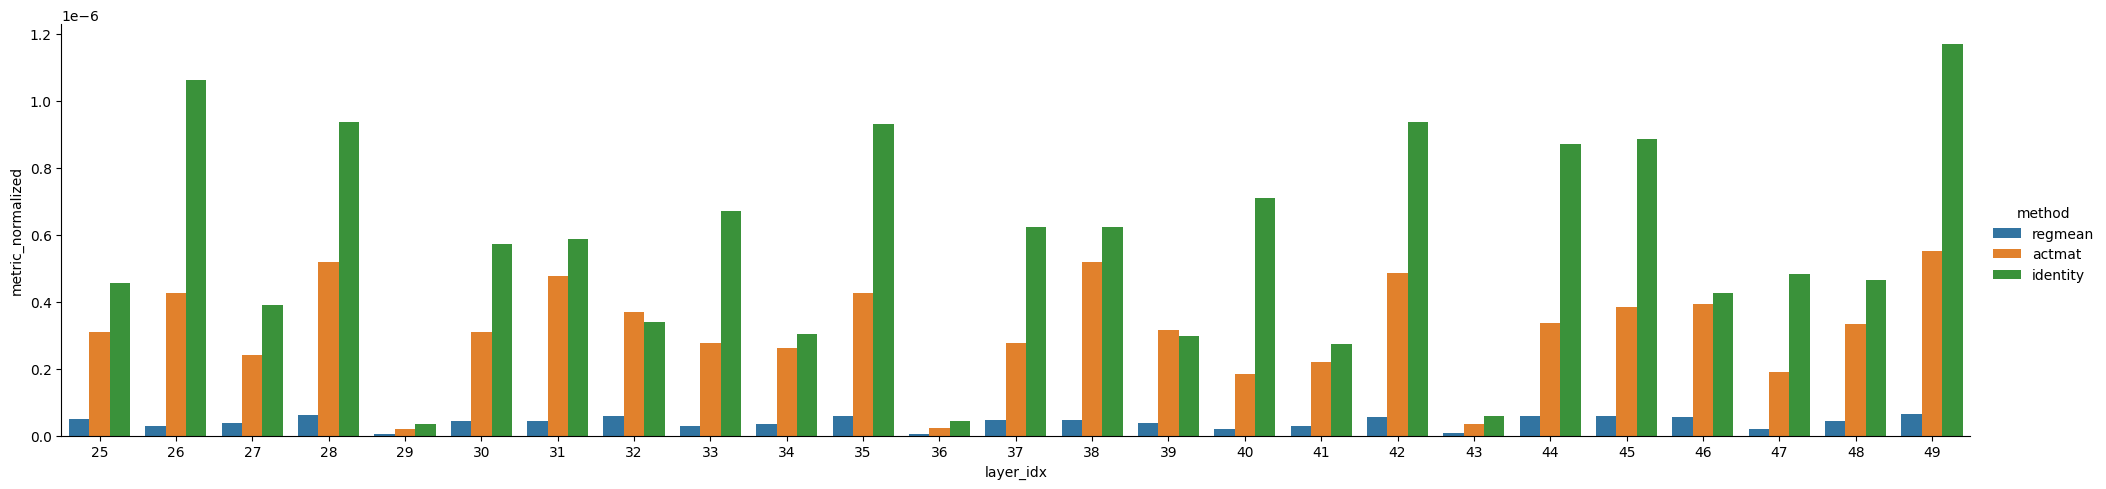

In [38]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("../artifacts/analysis/rm-loss/rm_loss_general.csv")
dfp = df[df["metric_type"] == "rm_loss"]
dfp = dfp[df["model"] == "Olmo-3-7b"]
# dfp = dfp[df["model"] == "t5-large"]
# dfp = dfp[df["model"] == "ViT-L-14"]
dfp["metric_normalized"] = dfp["metric"] / (dfp["Do"] * dfp["Di"])
dfp = dfp[dfp["method"].isin(["actmat", "regmean", "identity"])]
dfp = dfp[(dfp["layer_idx"] >= 25) & (dfp["layer_idx"] < 50)]

g = sns.catplot(
    dfp,
    x="layer_idx",
    y="metric_normalized",
    hue="method",
    hue_order=["regmean", "actmat", "identity"],
    # style="method",
    kind="bar",
    # markers=True,
    aspect=4,
)
# g.set(yscale="log")
# dfp = dfp.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
# dfp = dfp.reindex(["identity", "actmat", "regmean"])
# dfp.style.format("{:.2e}")

/tmp/ipykernel_1023923/4210680141.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfp = dfp[df["model"] == model]


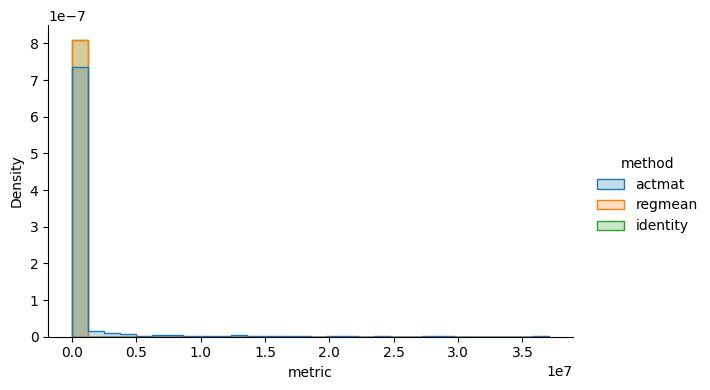

In [12]:
import pandas as pd
import seaborn as sns

metric_type = "cosine_similarity"
# metric_type = "rm_loss"
# model = "Olmo-3-7b"
model = "ViT-B-16"
df = pd.read_csv("../artifacts/analysis/rm-loss/rm_loss_general.csv")
dfp = df[df["metric_type"] == metric_type]
dfp = df[df["method"].isin(["regmean", "identity", "actmat"])]
dfp = dfp[df["model"] == model]

g = sns.displot(
    dfp,
    x="metric",
    hue="method",
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
    bins=30,
    height=4,
    aspect=1.5,
)

In [2]:
dfp

,model,method,layer,layer_idx,metric_type,metric,Di,Do
27712,Olmo-3-7b,actmat,lm_head.weight,0,rm_loss,5450.107422,4096,100278
27720,Olmo-3-7b,actmat-identity-inv,lm_head.weight,0,rm_loss,8017.191406,4096,100278
27728,Olmo-3-7b,regmean,lm_head.weight,0,rm_loss,690.046875,4096,100278
27736,Olmo-3-7b,identity,lm_head.weight,0,rm_loss,5185.236816,4096,100278
27744,Olmo-3-7b,actmat,model.layers.0.mlp.down_proj.weight,1,rm_loss,0.099288,11008,4096
...,...,...,...,...,...,...,...,...
34872,Olmo-3-7b,identity,model.layers.9.self_attn.q_proj.weight,223,rm_loss,2.370270,4096,4096
34880,Olmo-3-7b,actmat,model.layers.9.self_attn.v_proj.weight,224,rm_loss,5.834961,4096,4096
34888,Olmo-3-7b,actmat-identity-inv,model.layers.9.self_attn.v_proj.weight,224,rm_loss,19.214134,4096,4096
34896,Olmo-3-7b,regmean,model.layers.9.self_attn.v_proj.weight,224,rm_loss,0.742409,4096,4096


In [ ]:
# import pandas as pd
# import seaborn as sns

# df = pd.read_csv("../artifacts/analysis/cov-estimate-error/cov-estimate-error.csv")
# dfp = df.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
# dfp = dfp.reindex(["identity", "actmat"])
# dfp.style.format("{:.2e}")

# import pandas as pd
# import seaborn as sns

# df = pd.read_csv("../artifacts/analysis/rm-loss/rm_loss_general.csv")
# dfp = df[df["metric_type"] == "rm_loss"]
# dfp = dfp.pivot_table(index="method", columns="model", values="metric", aggfunc="sum")
# dfp = dfp.reindex(["identity", "actmat", "regmean"])
# dfp.style.format("{:.2e}")

## Error terms

### Figure: layer-wise error terms

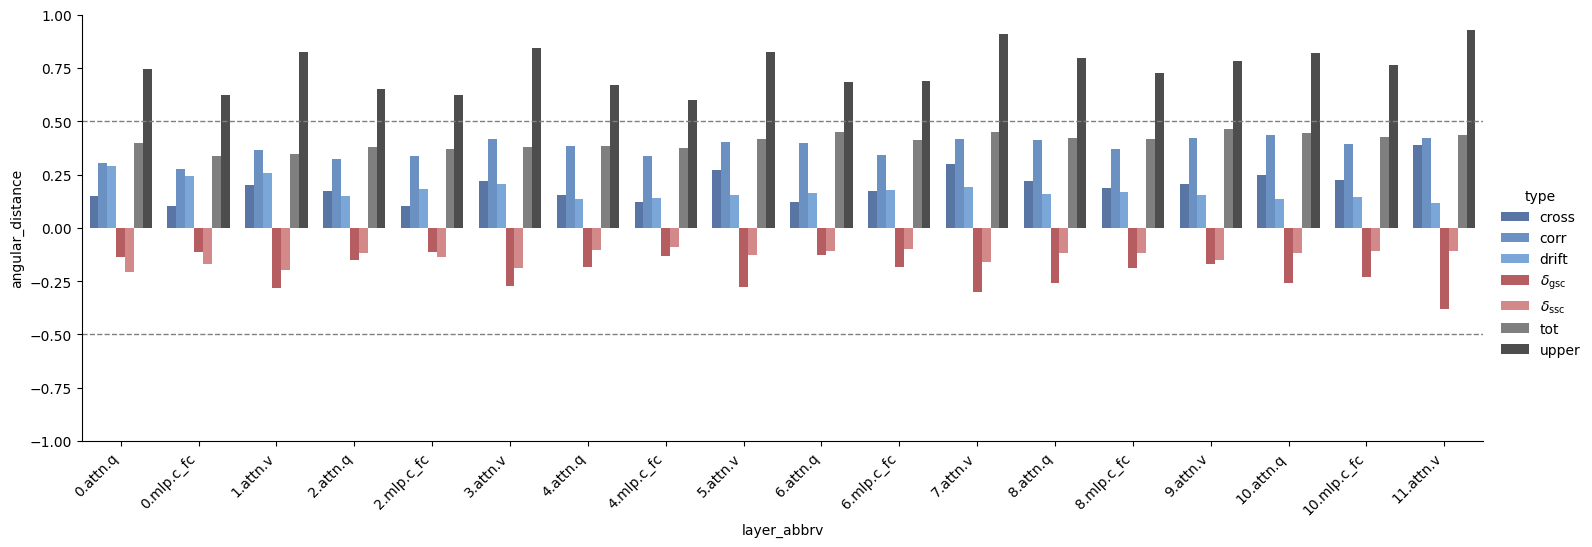

In [18]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

model = "ViT-B-16"
results_dir = f"../artifacts/results/{model}/group-fft-8"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))

# Filters:
# df = df[df["dataset"] == "Cars"]
# df = df[df["dataset"] == "DTD"]
df = df[df["dataset"] == "MNIST"]
# df = df[df["dataset"] == "SVHN"]
df = df[df["layer_idx"] % 4 == 0]

# Make layer abbrv
replace_strs = {
    "model.visual.transformer.resblocks.": "",
    ".weight": "",
}

df["layer_abbrv"] = df["layer_name"]
for old, new in replace_strs.items():
    df["layer_abbrv"] = df["layer_abbrv"].str.replace(old, new, regex=False)

hue_order = [
    "cross",
    "corr",
    "drift",
    r"$\delta_\text{gsc}$",
    r"$\delta_\text{ssc}$",
    "tot",
    "upper",
]

palette = {
    "cross": "#4C72B0",  # blues for the ε error terms
    "corr": "#5B8FCF",
    "drift": "#6BA6E8",
    r"$\delta_\text{gsc}$": "#C44E52",  # reds for the δ slack terms
    r"$\delta_\text{ssc}$": "#E07B7E",
    "tot": "#7F7F7F",  # grey for the total
    "upper": "#4D4D4D",  # darker grey for the triangle-inequality bound
}

g = sns.catplot(
    data=df,
    x="layer_abbrv",
    y="angular_distance",
    kind="bar",
    hue="type",
    aspect=3,
    hue_order=hue_order,
    palette=palette,
)
g.set_xticklabels(rotation=45, ha="right")
g.set(ylim=(-1.0, 1.0))
g.ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
g.ax.axhline(-0.5, color="grey", linestyle="--", linewidth=1)

### Figure: dataset-wise error terms

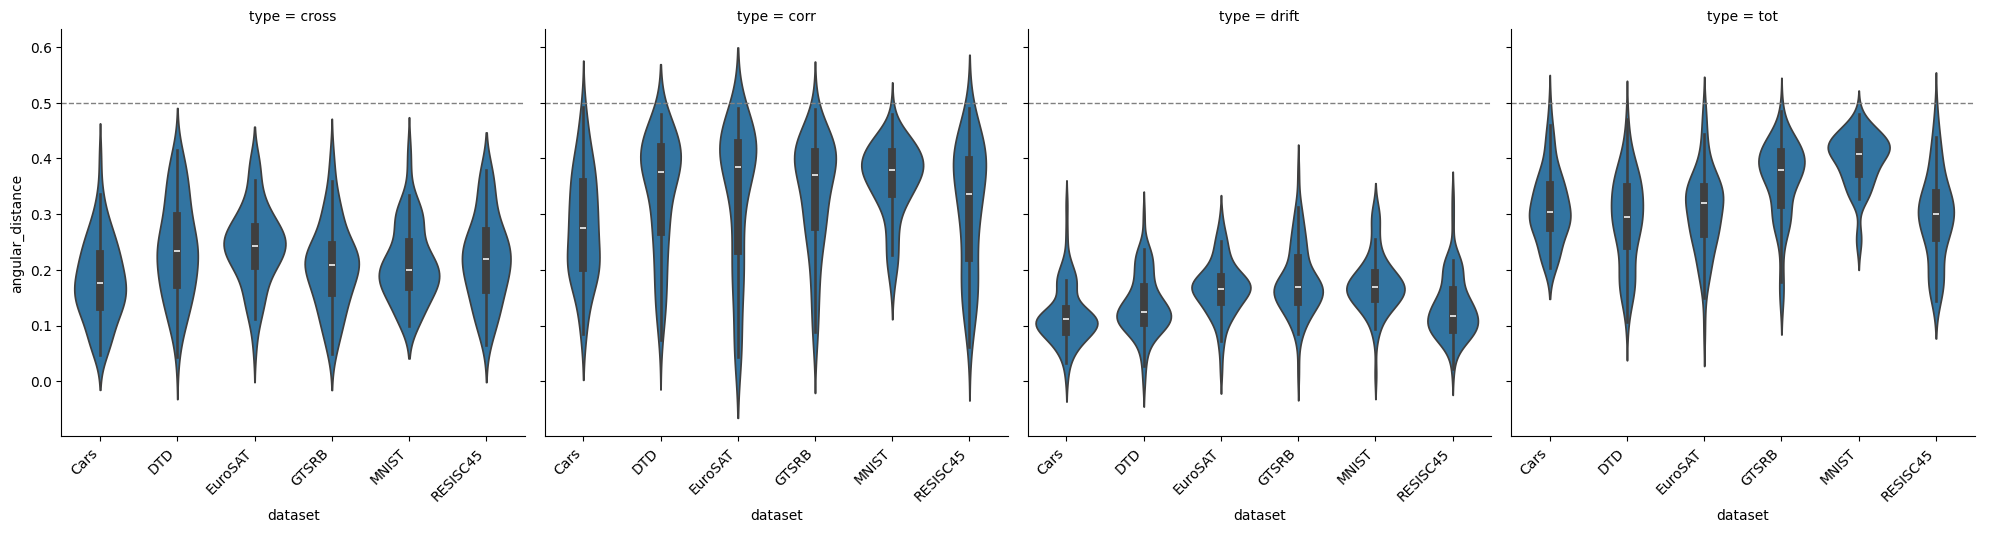

In [ ]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

model = "ViT-B-16"
results_dir = f"../artifacts/results/{model}/group-fft-8"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))
df = df[df["type"].isin(["cross", "corr", "drift", "tot"])]

g = sns.catplot(data=df, x="dataset", y="angular_distance", kind="violin", col="type")
g.set_xticklabels(rotation=45, ha="right")
for ax in g.axes.flat:
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)

### Table: Error Terms

In [23]:
import os
import os.path as osp

import numpy as np
import pandas as pd
import seaborn as sns

model = "ViT-B-16"
results_dir = f"../artifacts/results/{model}/group-fft-8"
df = pd.read_csv(osp.join(results_dir, "error_terms.csv"))

dfp = df.pivot_table(index="type", columns="dataset", values="angular_distance")
dfp

dataset,Cars,DTD,EuroSAT,GTSRB,MNIST,RESISC45
type,,,,,,
$\delta_\text{gsc}$,-0.179592,-0.307068,-0.303579,-0.227361,-0.219166,-0.263689
$\delta_\text{ssc}$,-0.086386,-0.114179,-0.134116,-0.135077,-0.129760,-0.106676
corr,0.278984,0.337374,0.333555,0.336815,0.360813,0.312180
cross,0.180975,0.237507,0.242447,0.206055,0.211024,0.220130
drift,0.119398,0.136773,0.167534,0.180341,0.174745,0.133614
tot,0.313380,0.290408,0.305841,0.360772,0.397655,0.295558
upper,0.579358,0.711655,0.743537,0.723210,0.746582,0.665924


## Figure: Layer-wise Cosine similarity histogram

In [40]:
import argparse
import math
import os
import os.path as osp
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

sys.path.append("..")

from src.vit.experts import ViTExpert, optional_sidecar  # noqa: E402

abs_cos = lambda a, b: ((a * b).sum() / (a.norm() * b.norm())).abs().item()

DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

# method -> effective covariance estimate; same cov_est_fn(d, c) contract as the
# table. regmean is the trivial reference (|cos| == 1 everywhere).
configs = {
    "regmean": lambda d, c: c,
    "actmat": lambda d, c: d.T @ d,
    "identity": lambda d, c: torch.eye(c.shape[-1]),
}

experts_dir = osp.join(
    "../artifacts/checkpoints", "ViT-B-16", f"group-fft-8", "experts"
)
base = ViTExpert(weights_path=osp.join(experts_dir, DATASETS[0], "pretrained.pt"))
experts = [
    ViTExpert(
        weights_path=osp.join(experts_dir, ds, "finetuned.pt"),
        covariance_path=optional_sidecar(osp.join(experts_dir, ds), "covariance.pt"),
    )
    for ds in DATASETS
]

rows = []  # one |cos| per (task, layer, method)
for ds, exp in zip(DATASETS, experts):
    for layer in exp.get_layers():
        c, d = exp.get_layer_cov(layer), exp.get_layer_params(layer)
        if c is None or d.ndim != 2 or c.shape[-1] != d.shape[-1]:
            continue
        c, d = c.float(), (d - base.get_layer_params(layer)).float()
        for method, fn in configs.items():
            rows.append(
                {"method": method, "abs_cos": abs_cos(c, fn(d, c)), "dataset": ds}
            )

In [39]:
df = pd.DataFrame(rows)
g = sns.displot(
    df,
    x="abs_cos",
    hue="method",
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
    # col="dataset",
    # col_wrap=3,
    bins=30,
    height=4,
    aspect=1.5,
)
g.set_axis_labels(r"$|\cos(c,\ \hat c)|$", "density")

ValueError: Could not interpret value `abs_cos` for `x`. An entry with this name does not appear in `data`.

## Figure: Layer-wise RM Loss Hist

In [26]:
import argparse
import math
import os
import os.path as osp
import sys
from tqdm import tqdm

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

sys.path.append("..")

from src.vit.experts import ViTExpert, optional_sidecar  # noqa: E402

tr_abt = lambda a, b: (a * b).sum()
pinv = lambda c: torch.linalg.pinv(c, hermitian=True)  # c is symmetric PSD

# ***************************************************************************
# Regmean objective
# ***************************************************************************


def compute_rm_loss(w_test, w_t, c_t):
    """Compute the RegMean loss for linear layer at a given w

    Args:
        w_test: (Do, Di)      merged delta (w* - w_0)
        w_t:    (T, Do, Di)   per-expert deltas
        c_t:    (T, Di, Di)   per-expert (real) covariances
    """
    w_test = w_test.unsqueeze(0)
    loss_1 = tr_abt(w_test @ c_t, w_test)
    loss_2 = tr_abt(w_t @ c_t, w_t)
    loss_3 = tr_abt(w_t @ c_t, w_test)
    return loss_1 + loss_2 - 2 * loss_3


# ***************************************************************************
# Merge methods
# ***************************************************************************
def merge_actmat(w0: torch.Tensor, d: torch.Tensor, **kwargs):
    c = d.transpose(-2, -1) @ d
    return w0 + (d @ c).sum(dim=0) @ torch.linalg.pinv(c.sum(dim=0))


def merge_regmean(w0: torch.Tensor, d: torch.Tensor, c: torch.Tensor, **kwargs):
    return w0 + (d @ c).sum(dim=0) @ torch.linalg.pinv(c.sum(dim=0))


def merge_mean(w0: torch.Tensor, d: torch.Tensor, **kwargs):
    return w0 + d.mean(0)


DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

# method -> effective covariance estimate; same cov_est_fn(d, c) contract as the
# table. regmean is the trivial reference (|cos| == 1 everywhere).
configs = {"regmean": merge_regmean, "actmat": merge_actmat, "mean": merge_mean}

experts_dir = osp.join(
    "../artifacts/checkpoints", "ViT-B-16", f"group-fft-8", "experts"
)
base = ViTExpert(weights_path=osp.join(experts_dir, DATASETS[0], "pretrained.pt"))
experts = [
    ViTExpert(
        weights_path=osp.join(experts_dir, ds, "finetuned.pt"),
        covariance_path=optional_sidecar(osp.join(experts_dir, ds), "covariance.pt"),
    )
    for ds in DATASETS
]

rows = []
for layer in tqdm(experts[0].get_layers()):
    c = [exp.get_layer_cov(layer) for exp in experts]
    w = [exp.get_layer_params(layer) for exp in experts]
    w0 = base.get_layer_params(layer)
    if c[0] is None or w[0].ndim != 2:
        continue
    d = torch.stack([wt - w0 for wt in w])
    c = torch.stack(c)
    for method, fn in configs.items():
        rows.append(
            {
                "method": method,
                "layer": layer,
                "rm_loss": compute_rm_loss(fn(w0, d, c=c) - w0, d, c).item(),
                "Di": w0.shape[-1],
                "Do": w0.shape[-2],
            }
        )

100%|██████████| 206/206 [15:51<00:00,  4.62s/it]


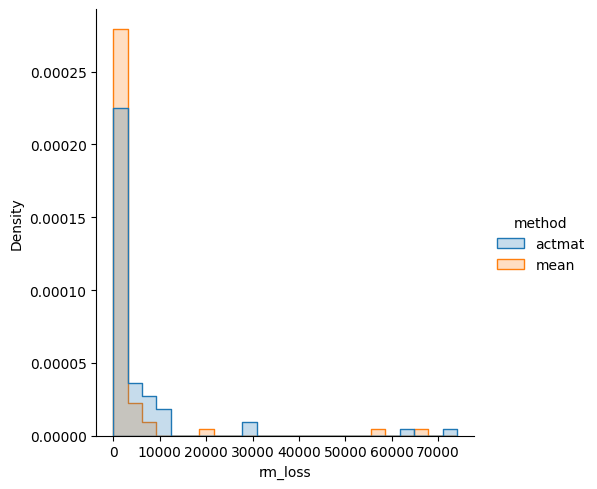

In [25]:
df = pd.DataFrame(rows)
df["rm_loss"] = df["rm_loss"].apply(lambda x: x.item())
df = df[df["method"].isin(["actmat", "mean"])]
g = sns.displot(
    df,
    x="rm_loss",
    hue="method",
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
    # col="dataset",
    # col_wrap=3,
    # bins=30,
    # height=4,
    # aspect=1.5,
)

## Table: Merge Performance (ViT)

In [1]:
import os
import os.path as osp
import json
import numpy as np
import pandas as pd
import seaborn as sns

# methods = ["regmean", "actmat"]
method_to_method = {
    "pretrained": "Pretrained",
    "experts": "Experts",
    "regmean": "RegMean",
    "mean": "Average",
    "isoc": "Iso-C",
    "tsv": "TSV",
    "wudi": "WUDI",
    "actmat": "ACTMat",
}
method_to_special_subdir = {
    "pretrained": "pretrained",
    "multitask": "multitask",
    "experts": "experts",
}


configs = [
    # {"model": "t5-base", "group": "main"},
    {"model": "ViT-B-16", "group": "fft-8"},
]
rows = []
for cfg in configs:
    model, group = cfg["model"], cfg["group"]
    root = f"../artifacts/results/{model}/group-{group}"
    for method in method_to_method:
        method_subdir = method_to_special_subdir.get(method, osp.join("merged", method))
        ft_filename = osp.join(root, method_subdir, "metrics.json")
        if not os.path.exists(ft_filename):
            print(f"[skipped] file dne {ft_filename}")
            continue
        with open(ft_filename, "r") as f:
            metrics = json.load(f)
            scores = [t["metrics"]["primary_score"] for t in metrics["tasks"]]
            avg_score = np.mean(scores)
            rows.append(
                {
                    "model": model,
                    "group": group,
                    "method": method,
                    "acc": avg_score,
                }
            )

[skipped] file dne ../artifacts/results/ViT-B-16/group-fft-8/pretrained/metrics.json
[skipped] file dne ../artifacts/results/ViT-B-16/group-fft-8/experts/metrics.json
[skipped] file dne ../artifacts/results/ViT-B-16/group-fft-8/merged/wudi/metrics.json


In [2]:
df = pd.DataFrame(rows)
df

,model,group,method,acc
0,ViT-B-16,fft-8,regmean,0.860572
1,ViT-B-16,fft-8,mean,0.714407
2,ViT-B-16,fft-8,isoc,0.859434
3,ViT-B-16,fft-8,tsv,0.868857
4,ViT-B-16,fft-8,actmat,0.878294
